In [ ]:
import os
import sys

# Get the current directory (Graphs folder)
current_dir = os.getcwd()
# Get the parent directory
parent_dir = os.path.abspath(os.path.join(current_dir, os.pardir))
# Add the parent directory to the sys.path
sys.path.append(parent_dir)
# Now you can import the RQAOA module

from concurrent.futures import ProcessPoolExecutor
from utils import *
from graphs import *
from RQAOA import *
from solvers import *
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt

In [ ]:
graph = generate_d_regular_graph(128, 4, seed=42, e_dist=[5, 1])
edges, adj_mat = graph_to_array(graph)
max_freq = get_max_frequency(edges, adj_mat)

opt_cost, mipgap, solution_list = find_ground_state_ising(graph)

In [18]:
max_workers=16
# Partial function for QAOA expectation cost
qaoa = partial(QAOA_Expectation_Cost, edges, adj_mat)

# Define the grid of gamma and beta values
gamma_vals = np.arange(0, np.pi, 1/(2*max_freq + 1))
beta_vals = np.arange(0, np.pi/2, np.pi/50)

# Create a meshgrid for gamma and beta
gamma, beta = np.meshgrid(gamma_vals, beta_vals)

# Flatten the meshgrid to create pairs of (gamma, beta)
params = np.column_stack((gamma.ravel(), beta.ravel()))

# Compute QAOA costs using parallel processing
with ProcessPoolExecutor(max_workers=max_workers) as executor:
    cost_values = np.array(list(executor.map(qaoa, params))).reshape(gamma.shape)

In [19]:
# Generate entries from 0 to π with spacing 1/(2*max_freq + 1)
entries_list = np.arange(0, np.pi + (np.pi)/(2*max_freq), (np.pi)/(2*max_freq))

# Compute the optimal betas for each gamma in entries_list
cbeta = partial(optimal_beta, edges, adj_mat)
opt_betas = [cbeta(g) for g in entries_list]

# Partial function for computing cost based on gamma
qaoa_gamma = partial(gamma_cost, edges, adj_mat)

# Compute costs in parallel
with ProcessPoolExecutor(max_workers=max_workers) as executor:
    costs = list(executor.map(qaoa_gamma, entries_list))

# Normalize the costs
#costs = [cost / opt_cost for cost in costs]
costs = [cost for cost in costs]

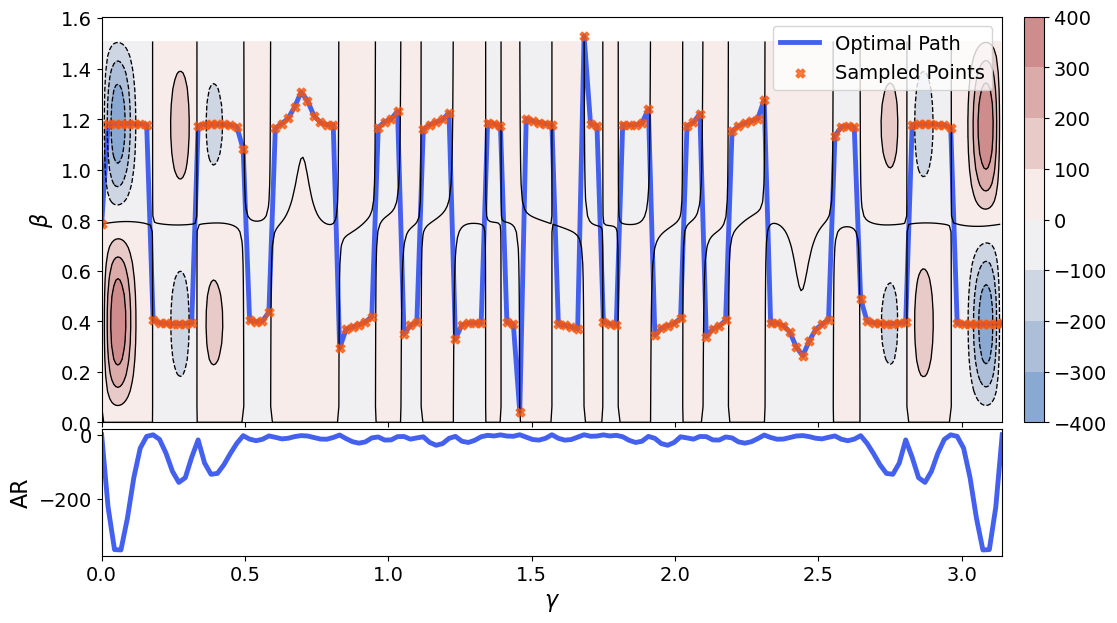

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec

# Use a Seaborn style for clean visuals
#sns.set(style='whitegrid')
linecolor = "#4361ee"

# Create a GridSpec layout with 2 rows and 1 column, sharing the x-axis
fig = plt.figure(figsize=(14, 7))
gs = gridspec.GridSpec(2, 1, height_ratios=[0.8, 0.25])

# Decrease the spacing between the plots
gs.update(hspace=0.025)  # Reduce the height space between subplots

# First subplot: Contour plot with refined colors
ax2 = fig.add_subplot(gs[1, 0])
ax1 = fig.add_subplot(gs[0, 0], sharex=ax2)
#cp = ax1.contourf(gamma, beta, cost_values / opt_cost, cmap='vlag', alpha=0.65)
#ax1.contour(gamma, beta, cost_values / opt_cost, colors='black', linewidths=0.95)
cp = ax1.contourf(gamma, beta, cost_values, cmap='vlag', alpha=0.65)
ax1.contour(gamma, beta, cost_values, colors='black', linewidths=0.95)

# Plot data with updated labels and legend
ax1.plot(entries_list, opt_betas, color=linecolor, linewidth=3.5, label='Optimal Path', zorder=1)
ax1.scatter(entries_list, opt_betas, color="#fb5607", label='Sampled Points', marker='X', s=40, alpha=0.75, zorder=2)
ax1.set_ylabel(r'$\beta$', fontsize=16)  # Increased y-axis label font size
ax1.legend(fontsize=14)  # Increased legend font size

# Remove x-axis labels from the first plot to avoid redundancy
ax1.label_outer()

# Add colorbar to the contour plot with increased font size
cbar = fig.colorbar(cp, ax=ax1, orientation='vertical', pad=0.02)
cbar.ax.tick_params(labelsize=14)  # Increased colorbar tick font size

# Second subplot: Line plot with the adjusted dimensions
ax2.plot(entries_list, costs, color=linecolor, linewidth=3.5, linestyle='-')
ax2.set_xlabel(r'$\gamma$', fontsize=16)  # Increased x-axis label font size
ax2.set_ylabel('AR', fontsize=16)  # Increased y-axis label font size

# Adjust tick label font size for both subplots
ax1.tick_params(axis='both', which='major', labelsize=14)  # Increased tick label font size for ax1
ax2.tick_params(axis='both', which='major', labelsize=14)  # Increased tick label font size for ax2

# Adjust the position of the second plot to match the width of the first plot without the color bar
pos1 = ax1.get_position()  # Get the original position of the first plot
pos2 = ax2.get_position()  # Get the original position of the second plot
ax2.set_position([pos1.x0, pos2.y0, pos1.width, pos2.height])
ax2.set_xlim(0, entries_list[-1])

# Save the figure with tight layout
plt.savefig('Weighted_2Local_Path.pdf', bbox_inches='tight')
# Display the plots
plt.show()


In [ ]:
graph = generate_d_regular_graph(128, 4, seed=42)
edges, adj_mat = graph_to_array(graph)
max_freq = get_max_frequency(edges, adj_mat)

opt_cost, mipgap, solution_list = find_ground_state_ising(graph)

In [ ]:
max_workers=16
# Partial function for QAOA expectation cost
qaoa = partial(QAOA_Expectation_Cost, edges, adj_mat)

# Define the grid of gamma and beta values
gamma_vals = np.arange(0, np.pi + 1/(2*max_freq + 1), 1/(2*max_freq + 1))
beta_vals = np.arange(0, np.pi/2, np.pi/50)

# Create a meshgrid for gamma and beta
gamma, beta = np.meshgrid(gamma_vals, beta_vals)

# Flatten the meshgrid to create pairs of (gamma, beta)
params = np.column_stack((gamma.ravel(), beta.ravel()))

# Compute QAOA costs using parallel processing
with ProcessPoolExecutor(max_workers=max_workers) as executor:
    cost_values = np.array(list(executor.map(qaoa, params))).reshape(gamma.shape)

# Generate entries from 0 to π with spacing 1/(2*max_freq + 1)
entries_list = np.arange(0, np.pi + (np.pi)/(2*max_freq + 1), (np.pi)/(2*max_freq + 1))

# Compute the optimal betas for each gamma in entries_list
cbeta = partial(optimal_beta, edges, adj_mat)
opt_betas = [cbeta(g) for g in entries_list]

# Partial function for computing cost based on gamma
qaoa_gamma = partial(gamma_cost, edges, adj_mat)

# Compute costs in parallel
with ProcessPoolExecutor(max_workers=max_workers) as executor:
    costs = list(executor.map(qaoa_gamma, entries_list))

# Normalize the costs
#costs = [cost / opt_cost for cost in costs]
costs = [cost for cost in costs]

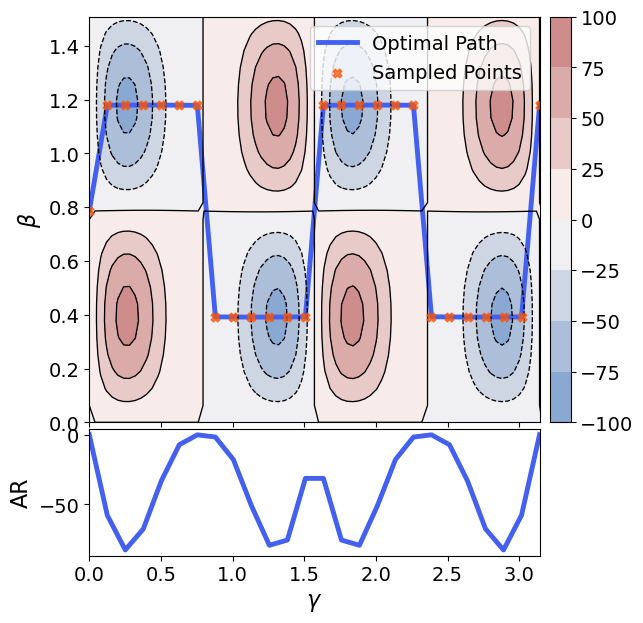

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec

# Use a Seaborn style for clean visuals
#sns.set(style='whitegrid')
linecolor = "#4361ee"

# Create a GridSpec layout with 2 rows and 1 column, sharing the x-axis
fig = plt.figure(figsize=(7, 7))
gs = gridspec.GridSpec(2, 1, height_ratios=[0.8, 0.25])

# Decrease the spacing between the plots
gs.update(hspace=0.025)  # Reduce the height space between subplots

# First subplot: Contour plot with refined colors
ax2 = fig.add_subplot(gs[1, 0])
ax1 = fig.add_subplot(gs[0, 0], sharex=ax2)
cp = ax1.contourf(gamma, beta, cost_values, cmap='vlag', alpha=0.65)
ax1.contour(gamma, beta, cost_values, colors='black', linewidths=0.95)

# Plot data with updated labels and legend
ax1.plot(entries_list, opt_betas, color=linecolor, linewidth=3.5, label='Optimal Path', zorder=1)
ax1.scatter(entries_list, opt_betas, color="#fb5607", label='Sampled Points', marker='X', s=40, alpha=0.75, zorder=2)
ax1.set_ylabel(r'$\beta$', fontsize=16)  # Increased y-axis label font size
ax1.legend(fontsize=14)  # Increased legend font size

# Remove x-axis labels from the first plot to avoid redundancy
ax1.label_outer()

# Add colorbar to the contour plot with increased font size
cbar = fig.colorbar(cp, ax=ax1, orientation='vertical', pad=0.02)
cbar.ax.tick_params(labelsize=14)  # Increased colorbar tick font size

# Second subplot: Line plot with the adjusted dimensions
ax2.plot(entries_list, costs, color=linecolor, linewidth=3.5, linestyle='-')
ax2.set_xlabel(r'$\gamma$', fontsize=16)  # Increased x-axis label font size
ax2.set_ylabel('AR', fontsize=16)  # Increased y-axis label font size

# Adjust tick label font size for both subplots
ax1.tick_params(axis='both', which='major', labelsize=14)  # Increased tick label font size for ax1
ax2.tick_params(axis='both', which='major', labelsize=14)  # Increased tick label font size for ax2

# Adjust the position of the second plot to match the width of the first plot without the color bar
pos1 = ax1.get_position()  # Get the original position of the first plot
pos2 = ax2.get_position()  # Get the original position of the second plot
ax2.set_position([pos1.x0, pos2.y0, pos1.width, pos2.height])
ax2.set_xlim(0, entries_list[-1])

# Save the figure with tight layout
plt.savefig('Unweighted_2Local_Path.pdf', bbox_inches='tight')
# Display the plots
plt.show()
